In [44]:
import pandas as pd

df = pd.read_csv("custom_tree_experiments_results.csv")

df.head()


,system_name,max_depth,cost_function,alpha,nodes_before,leaves_before,depth_before,nodes_after,leaves_after,depth_after,NRMSE_Train_Tree,NRMSE_Test_Tree,NRMSE_Train_Affine_before,NRMSE_Test_Affine_before,NRMSE_Train_Affine_after,NRMSE_Test_Affine_after
0,Jet,4,basic,0.001,31,16,4,25,13,4,0.042073,0.043932,0.000863,0.000867,0.000937,0.000946
1,Jet,4,basic,0.010,31,16,4,7,4,2,0.042073,0.043932,0.000863,0.000867,0.003348,0.003374
2,Jet,4,basic,0.050,31,16,4,5,3,2,0.042073,0.043932,0.000863,0.000867,0.005980,0.006017
3,Jet,4,basic,0.100,31,16,4,3,2,1,0.042073,0.043932,0.000863,0.000867,0.013039,0.013189
4,Jet,4,basic,0.500,31,16,4,3,2,1,0.042073,0.043932,0.000863,0.000867,0.013039,0.013189


In [46]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180 entries, 0 to 179
Data columns (total 16 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   system_name                180 non-null    object 
 1   max_depth                  180 non-null    int64  
 2   cost_function              180 non-null    object 
 3   alpha                      180 non-null    float64
 4   nodes_before               180 non-null    int64  
 5   leaves_before              180 non-null    int64  
 6   depth_before               180 non-null    int64  
 7   nodes_after                180 non-null    int64  
 8   leaves_after               180 non-null    int64  
 9   depth_after                180 non-null    int64  
 10  NRMSE_Train_Tree           180 non-null    float64
 11  NRMSE_Test_Tree            180 non-null    float64
 12  NRMSE_Train_Affine_before  180 non-null    float64
 13  NRMSE_Test_Affine_before   180 non-null    float64

In [97]:
systems = df["system_name"].unique()
print(systems)

['Jet' 'Exponential' 'NL1' 'Tank' 'Steam' 'NL2']


In [20]:
import seaborn as sns
import matplotlib.pyplot as plt


def plot_alpha_vs_tree_size(df):

    systems = df["system_name"].unique()

    for system in systems:

        sub = df[df.system_name == system]

        # ---- NODES ----
        fig, ax = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

        sns.lineplot(
            data=sub,
            x="alpha",
            y="nodes_before",
            hue="cost_function",
            style="max_depth",
            markers=True,
            dashes=False,
            ax=ax[0]
        )

        sns.lineplot(
            data=sub,
            x="alpha",
            y="nodes_after",
            hue="cost_function",
            style="max_depth",
            markers=True,
            dashes=False,
            ax=ax[1]
        )

        ax[0].set_title(f"{system} — Nodes BEFORE pruning")
        ax[1].set_title(f"{system} — Nodes AFTER pruning")

        for a in ax:
            # a.set_xscale("log")
            a.set_xlabel("Alpha") # (log scale)
            a.set_ylabel("Number of Nodes")
            a.grid(True, alpha=0.3)

        plt.suptitle(f"{system}: Alpha vs Tree Nodes", fontsize=14)
        plt.tight_layout()
        plt.show()

        # ---- LEAVES ----
        fig, ax = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

        sns.lineplot(
            data=sub,
            x="alpha",
            y="leaves_before",
            hue="cost_function",
            style="max_depth",
            markers=True,
            dashes=False,
            ax=ax[0]
        )

        sns.lineplot(
            data=sub,
            x="alpha",
            y="leaves_after",
            hue="cost_function",
            style="max_depth",
            markers=True,
            dashes=False,
            ax=ax[1]
        )

        ax[0].set_title(f"{system} — Leaves BEFORE pruning")
        ax[1].set_title(f"{system} — Leaves AFTER pruning")

        for a in ax:
            # a.set_xscale("log")
            a.set_xlabel("Alpha ") # (log scale)
            a.set_ylabel("Number of Leaves")
            a.grid(True, alpha=0.3)

        plt.suptitle(f"{system}: Alpha vs Tree Leaves", fontsize=14)
        plt.tight_layout()
        plt.show()


In [2]:
plot_alpha_vs_tree_size(df)


NameError: name 'plot_alpha_vs_tree_size' is not defined

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt
import os

# systems list
systems = df["system_name"].unique()

for system in systems:
    sub = df[df["system_name"] == system]
    
    fig, ax = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
    
    
    sns.lineplot(
        data=sub,
        x="alpha",
        y="leaves_after",
        # hue="cost_function",
        style="max_depth",
        markers=True,
        dashes=True,  # dashed lines for leaves
        # legend=False  # hide extra legend to keep plot clean
        ax=ax[0]
    )

    sns.lineplot(
        data=sub,
        x="alpha",
        y="nodes_after",
        # hue="cost_function",
        style="max_depth",   # different markers for different depths
        markers=True,
        dashes=False,
        ax=ax[1]
    )

    ax[0].set_title(f"{system} — Leaves AFTER pruning")
    ax[1].set_title(f"{system} — Nodes AFTER pruning")


    
    ax[0].set_xlabel("Alpha ") # (log scale)
    ax[0].set_ylabel("Number of Leaves")
    ax[0].grid(True, alpha=0.3)
    ax[1].set_xlabel("Alpha ") # (log scale)
    ax[1].set_ylabel("Number of Nodes")
    ax[1].grid(True, alpha=0.3)

    plt.suptitle(f"{system}: Alpha vs Tree Leaves & Nodes", fontsize=14)
    plt.legend(title="Cost Function / Max Depth")
    plt.tight_layout()
    
    # os.makedirs(name=f"graphs/data_analysis/nodes_leaves_alpha/", exist_ok=True)
    # plt.savefig(f"graphs/data_analysis/nodes_leaves_alpha/{system}.png", dpi=300)
    
    plt.show()
    
    # plt.title(f"Effect of alpha on Nodes and Leaves after pruning ({system})")
    # plt.xlabel("Alpha")
    # plt.ylabel("Count")
    # plt.legend(title="Cost Function / Max Depth")
    # plt.show()


NameError: name 'df' is not defined

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt
import os

# systems list
systems = df["system_name"].unique()
sns.set_style("whitegrid")

for system in systems:
    sub = df[df["system_name"] == system].copy()
    sub["max_depth"] = sub["max_depth"].astype(str)  # treat as categorical for style

    fig, ax = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

    # --- Leaves Bar Plot ---
    sns.barplot(
        data=sub,
        x="alpha",
        y="leaves_after",
        hue="cost_function",
        errorbar=None,   # no confidence interval
        palette="pastel",
        ax=ax[0]
    )
    # Add numbers on bars
    for container in ax[0].containers:
        ax[0].bar_label(container, fmt='%.0f', label_type='edge', padding=2)

    # --- Nodes Bar Plot ---
    sns.barplot(
        data=sub,
        x="alpha",
        y="nodes_after",
        hue="cost_function",
        errorbar=None,
        palette="pastel",
        ax=ax[1]
    )

    # Add numbers on bars
    for container in ax[1].containers:
        ax[1].bar_label(container, fmt='%.0f', label_type='edge', padding=2)


    # Titles and labels
    ax[0].set_title(f"{system} — Leaves after pruning")
    ax[1].set_title(f"{system} — Nodes after pruning")

    ax[0].set_xlabel("Alpha")
    ax[0].set_ylabel("Count of Leaves")
    ax[0].grid(True, alpha=0.3)

    ax[1].set_xlabel("Alpha")
    ax[1].set_ylabel("Count of Nodes")
    ax[1].grid(True, alpha=0.3)

    plt.suptitle(f"{system}: Alpha vs Tree Leaves & Nodes", fontsize=14)

    # Place a single legend for both plots
    handles, labels = ax[0].get_legend_handles_labels()
    fig.legend(handles, labels, title="Cost Function", loc="upper right")

    plt.tight_layout(rect=[0, 0, 0.95, 0.95])
    os.makedirs(name=f"graphs/data_analysis/nodes_leaves_alpha/", exist_ok=True)
    plt.savefig(f"graphs/data_analysis/nodes_leaves_alpha/{system}.png", dpi=300)
    plt.show()
    


NameError: name 'df' is not defined

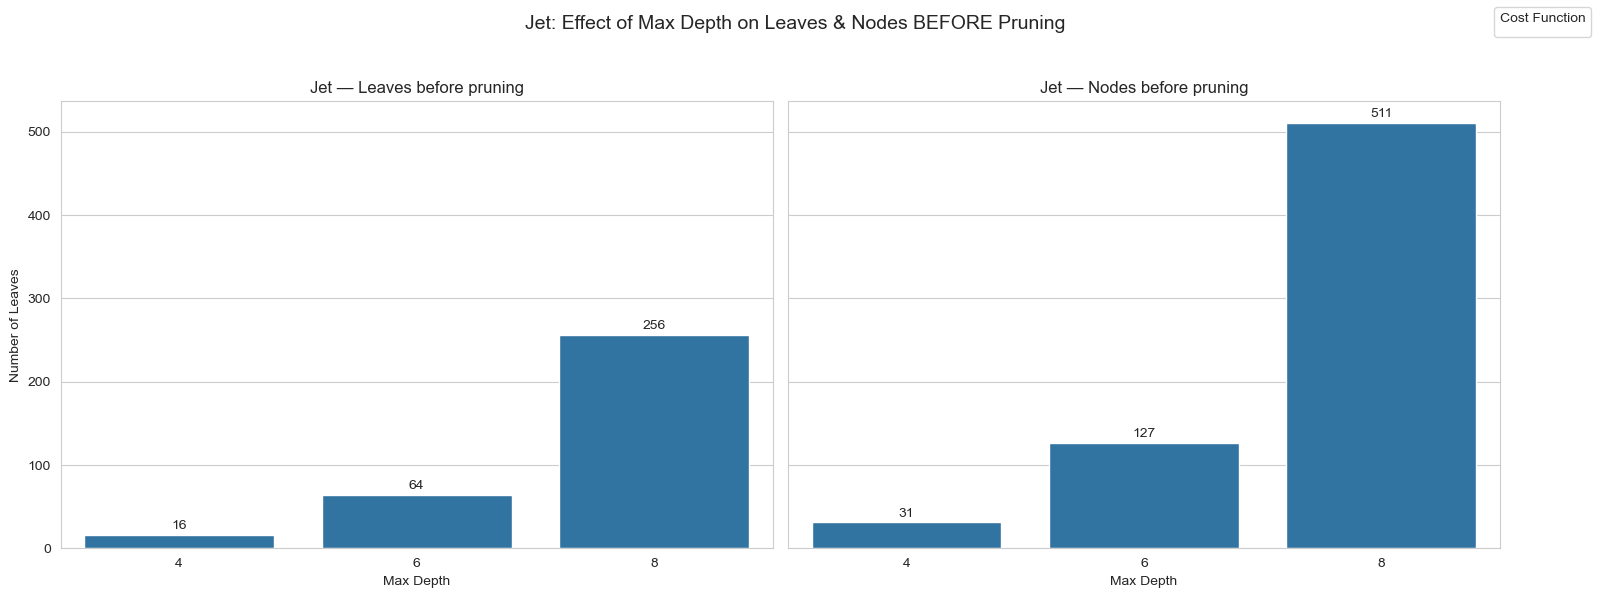

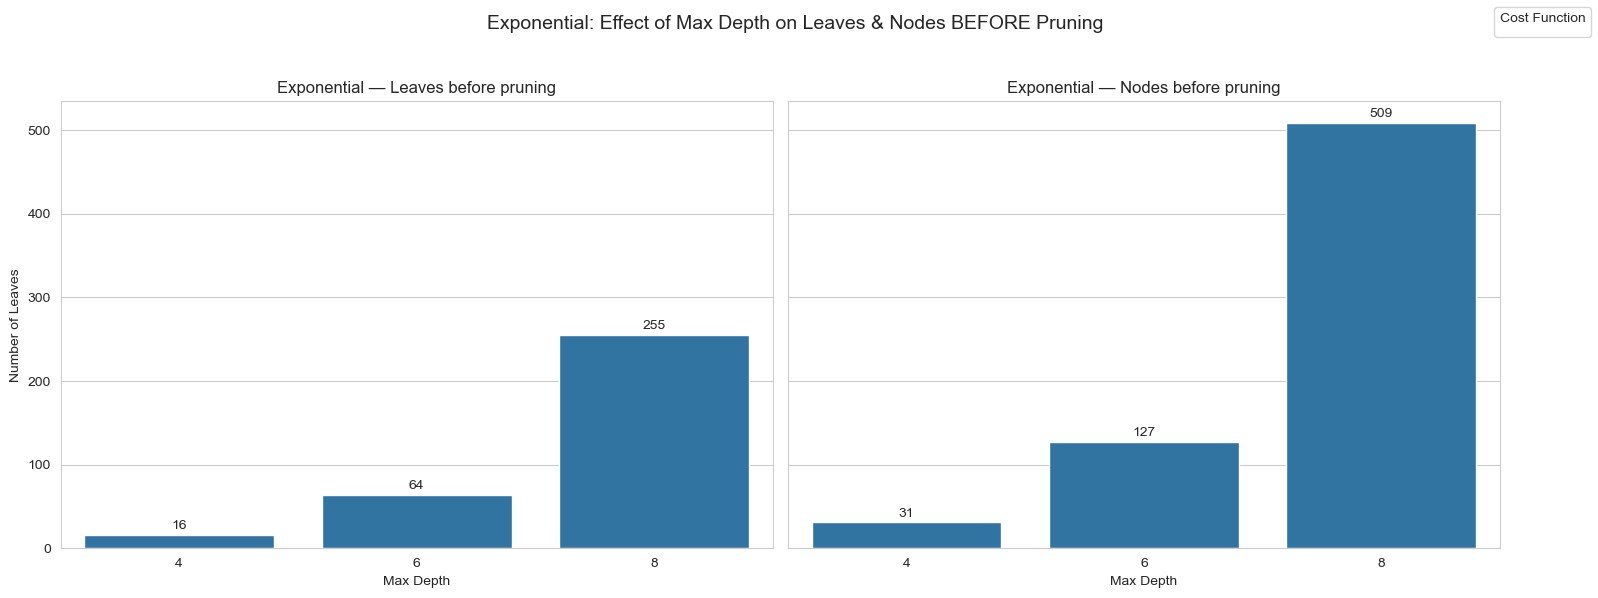

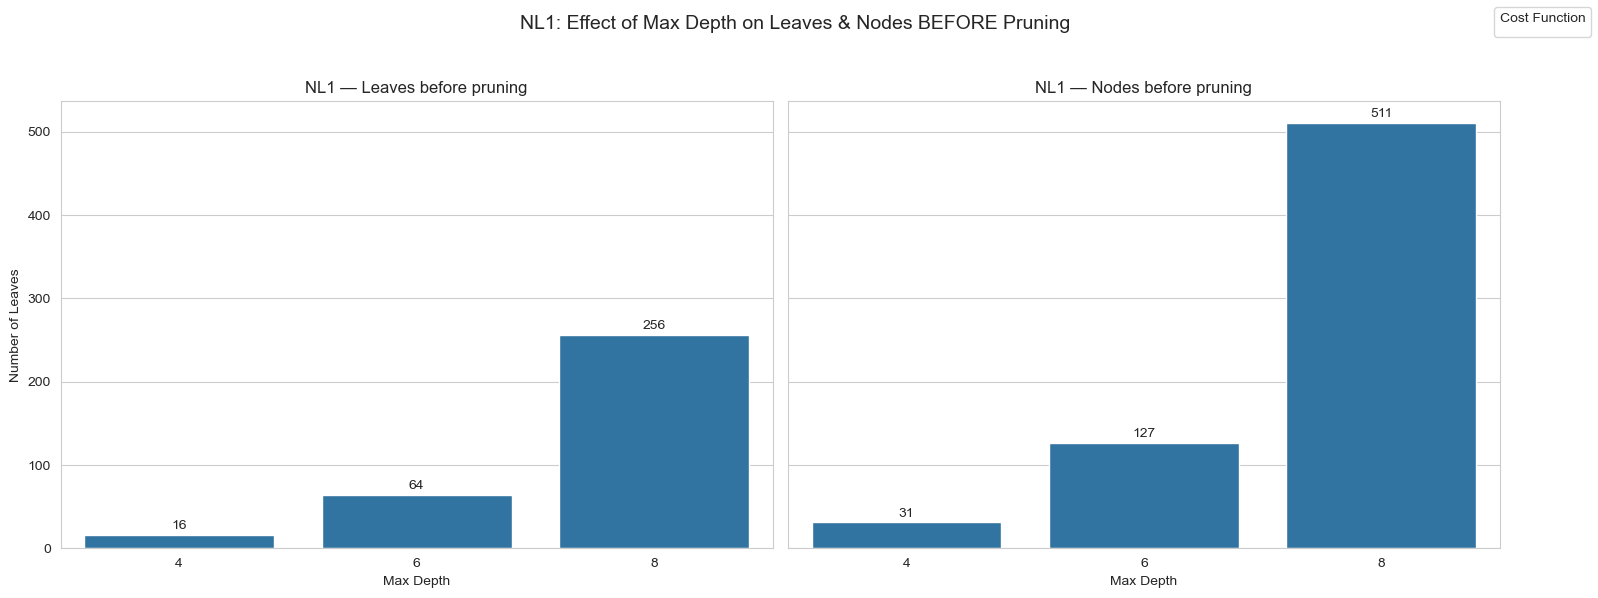

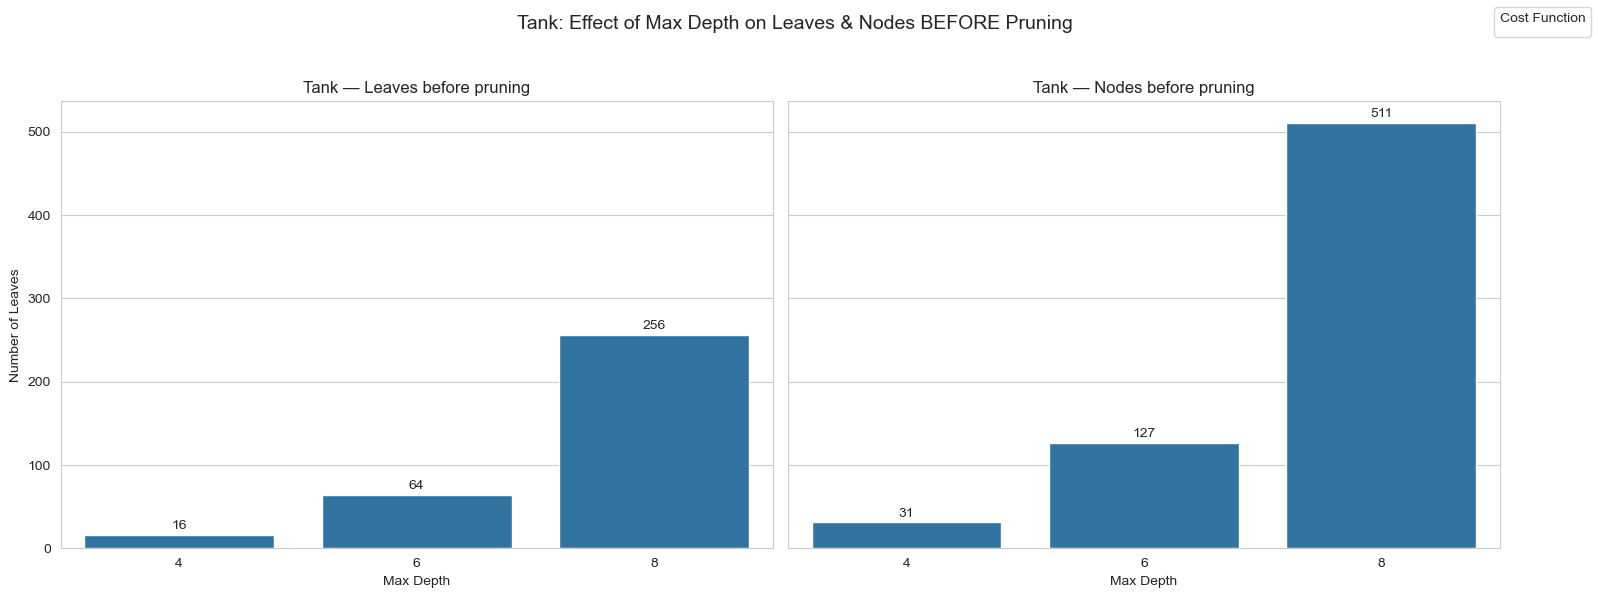

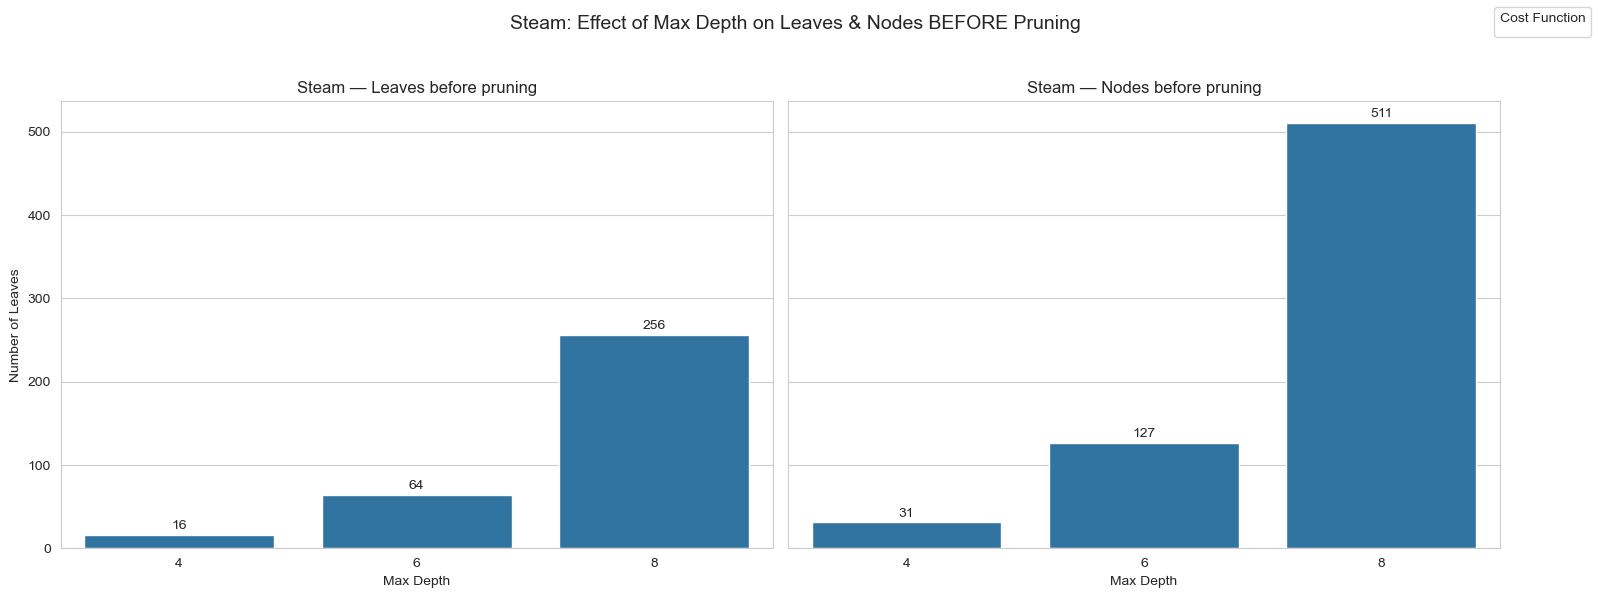

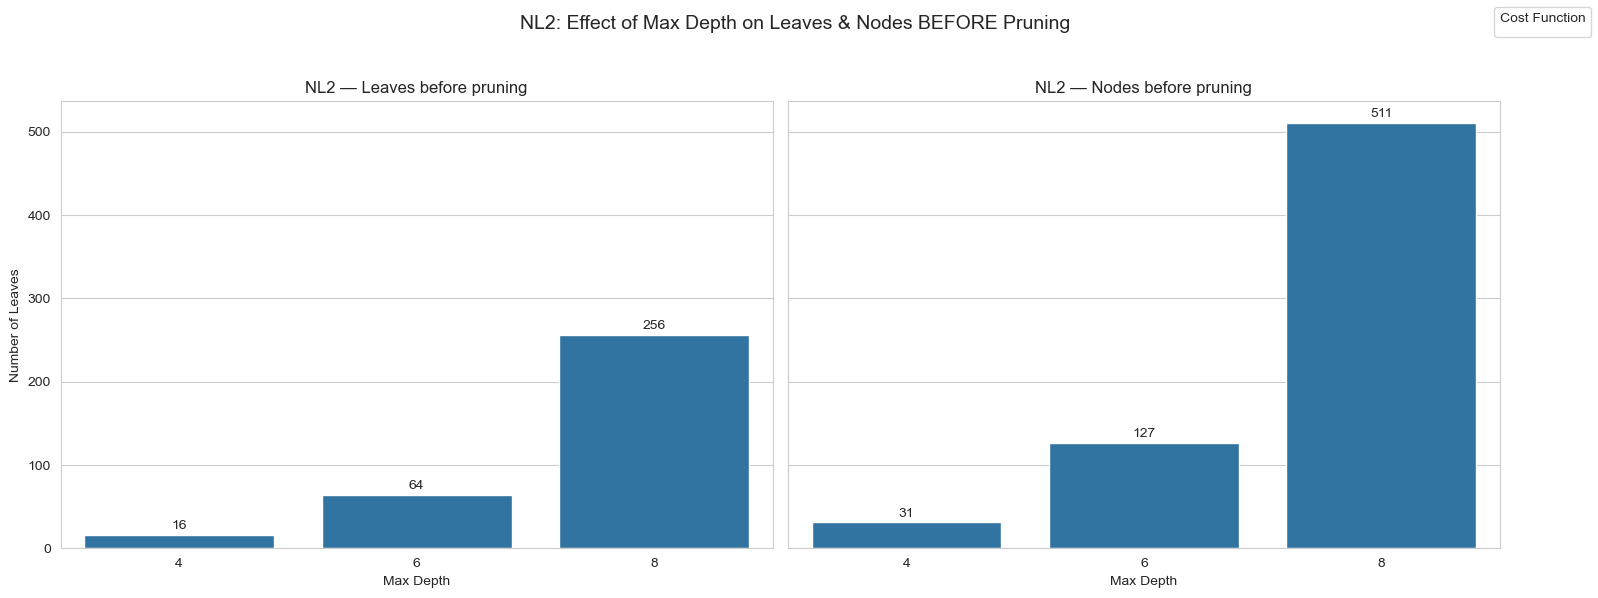

In [133]:
import seaborn as sns
import matplotlib.pyplot as plt

systems = df["system_name"].unique()
sns.set_style("whitegrid")

for system in systems:
    sub = df[df["system_name"] == system].copy()
    
    fig, ax = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

    # --- Leaves Before Pruning ---
    sns.barplot(
        data=sub,
        x="max_depth",
        y="leaves_before",
        # hue="cost_function",
        errorbar=None,
        # palette="pastel",
        ax=ax[0]
    )

    # Label bars with numbers
    for container in ax[0].containers:
        ax[0].bar_label(container, fmt='%.0f', label_type='edge', padding=2)

    # --- Nodes Before Pruning ---
    sns.barplot(
        data=sub,
        x="max_depth",
        y="nodes_before",
        # hue="cost_function",
        errorbar=None,
        # palette="pastel",
        ax=ax[1]
    )

    for container in ax[1].containers:
        ax[1].bar_label(container, fmt='%.0f', label_type='edge', padding=2)

    # Titles and labels
    ax[0].set_title(f"{system} — Leaves before pruning")
    ax[1].set_title(f"{system} — Nodes before pruning")

    ax[0].set_xlabel("Max Depth")
    ax[0].set_ylabel("Number of Leaves")
    ax[1].set_xlabel("Max Depth")
    ax[1].set_ylabel("Number of Nodes")

    # Single legend
    handles, labels = ax[0].get_legend_handles_labels()
    fig.legend(handles, labels, title="Cost Function", loc="upper right")

    plt.suptitle(f"{system}: Effect of Max Depth on Leaves & Nodes BEFORE Pruning", fontsize=14)
    plt.tight_layout(rect=[0, 0, 0.95, 0.95])

    os.makedirs(name=f"graphs/data_analysis/nodes_leaves_alpha/", exist_ok=True)
    plt.savefig(f"graphs/data_analysis/nodes_leaves_alpha/{system}-before.png", dpi=300)

    
    plt.show()


In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

systems = df["system_name"].unique()
sns.set_style("whitegrid")

for system in systems:
    sub = df[df["system_name"] == system].copy()
    # Combine cost_function and max_depth for grouping
    sub["group"] = sub["cost_function"] + " / " + sub["max_depth"].astype(str)

    fig, ax = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

    # --- Leaves Bar Plot ---
    sns.barplot(
        data=sub,
        x="alpha",
        y="leaves_after",
        hue="group",
        errorbar=None,
        palette="pastel",
        ax=ax[0]
    )

    # Add numbers on bars
    for container in ax[0].containers:
        ax[0].bar_label(container, fmt='%.0f', label_type='edge', padding=2)

    # --- Nodes Bar Plot ---
    sns.barplot(
        data=sub,
        x="alpha",
        y="nodes_after",
        hue="group",
        errorbar=None,
        palette="pastel",
        ax=ax[1]
    )

    for container in ax[1].containers:
        ax[1].bar_label(container, fmt='%.0f', label_type='edge', padding=2)

    # Titles and labels
    ax[0].set_title(f"{system} — Leaves after pruning")
    ax[1].set_title(f"{system} — Nodes after pruning")

    ax[0].set_xlabel("Alpha")
    ax[0].set_ylabel("Count of Leaves")
    ax[1].set_xlabel("Alpha")
    ax[1].set_ylabel("Count of Nodes")

    plt.suptitle(f"{system}: Alpha vs Leaves & Nodes (Grouped by Cost Function / Max Depth)", fontsize=14)

    # Single legend
    handles, labels = ax[0].get_legend_handles_labels()
    fig.legend(handles, labels, title="Cost Function / Max Depth", loc="upper right")

    plt.tight_layout(rect=[0, 0, 0.95, 0.95])

    os.makedirs(name=f"graphs/data_analysis/nodes_leaves_alpha/", exist_ok=True)
    plt.savefig(f"graphs/data_analysis/nodes_leaves_alpha/{system}.png", dpi=300)
    
    plt.show()


NameError: name 'df' is not defined

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_style("whitegrid")

systems = df["system_name"].unique()

for system in systems:

    sub = df[df["system_name"] == system].copy()

    fig, ax = plt.subplots(2, 2, figsize=(16, 12), sharex=True)

    # ---------------- TRAIN BEFORE ----------------
    sns.lineplot(
        data=sub,
        x="alpha",
        y="NRMSE_Train_Affine_before",
        hue="cost_function",
        style="max_depth",
        markers=True,
        ax=ax[0, 0]
    )
    ax[0, 0].set_title("Train NRMSE — Before Pruning")
    ax[0, 0].set_ylabel("NRMSE")

    # ---------------- TEST BEFORE ----------------
    sns.lineplot(
        data=sub,
        x="alpha",
        y="NRMSE_Test_Affine_before",
        hue="cost_function",
        style="max_depth",
        markers=True,
        ax=ax[0, 1]
    )
    ax[0, 1].set_title("Test NRMSE — Before Pruning")

    # ---------------- TRAIN AFTER ----------------
    sns.lineplot(
        data=sub,
        x="alpha",
        y="NRMSE_Train_Affine_after",
        hue="cost_function",
        style="max_depth",
        markers=True,
        ax=ax[1, 0]
    )
    ax[1, 0].set_title("Train NRMSE — After Pruning")
    ax[1, 0].set_ylabel("NRMSE")
    ax[1, 0].set_xlabel("Alpha")

    # ---------------- TEST AFTER ----------------
    sns.lineplot(
        data=sub,
        x="alpha",
        y="NRMSE_Test_Affine_after",
        hue="cost_function",
        style="max_depth",
        markers=True,
        ax=ax[1, 1]
    )
    ax[1, 1].set_title("Test NRMSE — After Pruning")
    ax[1, 1].set_xlabel("Alpha")

    # ---- Global formatting ----
    plt.suptitle(f"{system}: Effect of Pruning on NRMSE", fontsize=16)

    for a in ax.flat:
        a.grid(True, alpha=0.3)

    # single legend
    handles, labels = ax[0, 0].get_legend_handles_labels()
    fig.legend(handles, labels, title="Cost / Max Depth", loc="upper right")

    plt.tight_layout(rect=[0, 0, 0.92, 0.95])
    os.makedirs(name=f"graphs/data_analysis/nrmse/", exist_ok=True)
    plt.savefig(f"graphs/data_analysis/nrmse/{system}.png", dpi=300)
    plt.show()


NameError: name 'df' is not defined

In [141]:
df.head()

,system_name,max_depth,cost_function,alpha,nodes_before,leaves_before,depth_before,nodes_after,leaves_after,depth_after,NRMSE_Train_Tree,NRMSE_Test_Tree,NRMSE_Train_Affine_before,NRMSE_Test_Affine_before,NRMSE_Train_Affine_after,NRMSE_Test_Affine_after
0,Jet,4,basic,0.001,31,16,4,25,13,4,0.042073,0.043932,0.000863,0.000867,0.000937,0.000946
1,Jet,4,basic,0.010,31,16,4,7,4,2,0.042073,0.043932,0.000863,0.000867,0.003348,0.003374
2,Jet,4,basic,0.050,31,16,4,5,3,2,0.042073,0.043932,0.000863,0.000867,0.005980,0.006017
3,Jet,4,basic,0.100,31,16,4,3,2,1,0.042073,0.043932,0.000863,0.000867,0.013039,0.013189
4,Jet,4,basic,0.500,31,16,4,3,2,1,0.042073,0.043932,0.000863,0.000867,0.013039,0.013189


In [159]:
import numpy as np
# filter dataframe                                   
filtered_values = np.where((df["system_name"] == "Jet") & (df["cost_function"] == "basic") & (df["max_depth"] == 4) )
print(filtered_values)
filtered_df = df.loc[filtered_values]
filtered_df


(array([0, 1, 2, 3, 4]),)


,system_name,max_depth,cost_function,alpha,nodes_before,leaves_before,depth_before,nodes_after,leaves_after,depth_after,NRMSE_Train_Tree,NRMSE_Test_Tree,NRMSE_Train_Affine_before,NRMSE_Test_Affine_before,NRMSE_Train_Affine_after,NRMSE_Test_Affine_after
0,Jet,4,basic,0.001,31,16,4,25,13,4,0.042073,0.043932,0.000863,0.000867,0.000937,0.000946
1,Jet,4,basic,0.010,31,16,4,7,4,2,0.042073,0.043932,0.000863,0.000867,0.003348,0.003374
2,Jet,4,basic,0.050,31,16,4,5,3,2,0.042073,0.043932,0.000863,0.000867,0.005980,0.006017
3,Jet,4,basic,0.100,31,16,4,3,2,1,0.042073,0.043932,0.000863,0.000867,0.013039,0.013189
4,Jet,4,basic,0.500,31,16,4,3,2,1,0.042073,0.043932,0.000863,0.000867,0.013039,0.013189


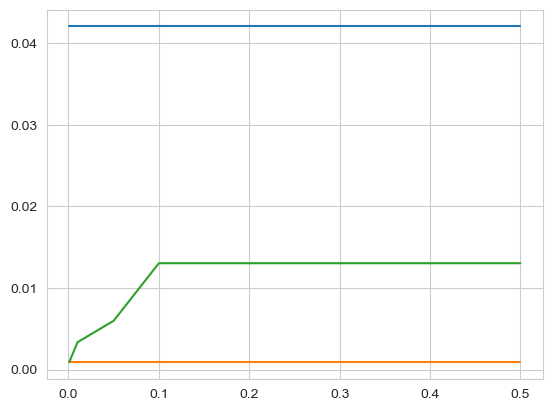

In [165]:
plt.plot(filtered_df["alpha"], filtered_df["NRMSE_Train_Tree"])
plt.plot(filtered_df["alpha"], filtered_df["NRMSE_Train_Affine_before"])
plt.plot(filtered_df["alpha"], filtered_df["NRMSE_Train_Affine_after"])
plt.show()